In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
GPU available: True


In [2]:
import kagglehub

path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
df = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")

print("Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nClass distribution (Diabetes_binary):")
print(df["Diabetes_binary"].value_counts())
print(df["Diabetes_binary"].value_counts(normalize=True).round(3))
print("\nBasic statistics:\n", df.describe())

Missing values:
 Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Class distribution (Diabetes_binary):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Diabetes_binary
0.0    0.861
1.0    0.139
Name: proportion, dtype: float64

Basic statistics:
        Diabetes_binary         HighBP       HighChol      CholCheck  \
count    253680.000000  253680.000000  253680.000000  253680.000000   
mean          0.139333       0.429001       0.424121

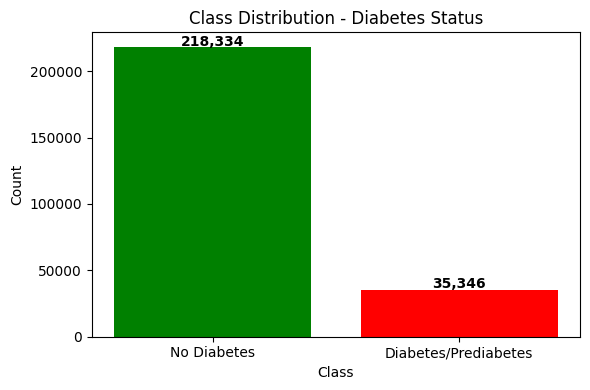

In [17]:
counts = df["Diabetes_binary"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No Diabetes", "Diabetes/Prediabetes"], counts.values, color=["green", "red"])
ax.set_title("Class Distribution - Diabetes Status")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [5]:
# RQ1: Predict Diabetes_binary from all other features
X_clf = df.drop(columns=["Diabetes_binary"])
y_clf = df["Diabetes_binary"]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_clf_train_s = scaler_clf.fit_transform(X_clf_train)
X_clf_test_s = scaler_clf.transform(X_clf_test)

print("Train size:", X_clf_train_s.shape)
print("Test size: ", X_clf_test_s.shape)

Train size: (202944, 21)
Test size:  (50736, 21)


In [6]:
# RQ2: Predict BMI from all features except Diabetes_binary
X_reg = df.drop(columns=["BMI", "Diabetes_binary"])
y_reg = df["BMI"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_s = scaler_reg.fit_transform(X_reg_train)
X_reg_test_s = scaler_reg.transform(X_reg_test)

print("Train size:", X_reg_train_s.shape)
print("Test size: ", X_reg_test_s.shape)

Train size: (202944, 20)
Test size:  (50736, 20)


In [7]:
# Baseline: Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_clf_train_s, y_clf_train)
y_pred_lr = lr_clf.predict(X_clf_test_s)

print("=== Logistic Regression ===")
print(classification_report(y_clf_test, y_pred_lr, target_names=["No Diabetes", "Diabetes"]))

=== Logistic Regression ===
              precision    recall  f1-score   support

 No Diabetes       0.88      0.98      0.92     43667
    Diabetes       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



In [8]:
class SimpleClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze()


def train_classifier(model, X_train, y_train, epochs=20, lr=0.001):
    # Class weight to handle 86/14 imbalance
    pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])

    dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train.values),
    )
    loader = DataLoader(dataset, batch_size=512, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loss_history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {avg_loss:.4f}")
        scheduler.step()

    return model, loss_history


input_dim = X_clf_train_s.shape[1]
simple_clf_nn = SimpleClassifierNN(input_dim)
simple_clf_nn, simple_clf_losses = train_classifier(
    simple_clf_nn, X_clf_train_s, y_clf_train, epochs=50
)

simple_clf_nn.eval()
with torch.no_grad():
    raw_preds = simple_clf_nn(torch.FloatTensor(X_clf_test_s))

# Threshold sweep to find best recall/precision trade-off
for t in [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]:
    y_pred = (raw_preds > t).int().numpy()
    r = classification_report(y_clf_test, y_pred, target_names=["No Diabetes", "Diabetes"], output_dict=True)
    print(f"Threshold {t:+.1f} | Recall: {r['Diabetes']['recall']:.3f} | "
          f"Precision: {r['Diabetes']['precision']:.3f} | F1: {r['Diabetes']['f1-score']:.3f}")

y_pred_simple_nn = (raw_preds > 0.5).int().numpy()
print("\n=== Simple Neural Network ===")
print(classification_report(y_clf_test, y_pred_simple_nn, target_names=["No Diabetes", "Diabetes"]))

Epoch 01/50 - Loss: 0.9042
Epoch 02/50 - Loss: 0.8671
Epoch 03/50 - Loss: 0.8635
Epoch 04/50 - Loss: 0.8617
Epoch 05/50 - Loss: 0.8608
Epoch 06/50 - Loss: 0.8591
Epoch 07/50 - Loss: 0.8590
Epoch 08/50 - Loss: 0.8586
Epoch 09/50 - Loss: 0.8579
Epoch 10/50 - Loss: 0.8579
Epoch 11/50 - Loss: 0.8569
Epoch 12/50 - Loss: 0.8569
Epoch 13/50 - Loss: 0.8570
Epoch 14/50 - Loss: 0.8567
Epoch 15/50 - Loss: 0.8562
Epoch 16/50 - Loss: 0.8561
Epoch 17/50 - Loss: 0.8560
Epoch 18/50 - Loss: 0.8560
Epoch 19/50 - Loss: 0.8562
Epoch 20/50 - Loss: 0.8560
Epoch 21/50 - Loss: 0.8557
Epoch 22/50 - Loss: 0.8556
Epoch 23/50 - Loss: 0.8554
Epoch 24/50 - Loss: 0.8555
Epoch 25/50 - Loss: 0.8556
Epoch 26/50 - Loss: 0.8558
Epoch 27/50 - Loss: 0.8555
Epoch 28/50 - Loss: 0.8555
Epoch 29/50 - Loss: 0.8554
Epoch 30/50 - Loss: 0.8555
Epoch 31/50 - Loss: 0.8552
Epoch 32/50 - Loss: 0.8553
Epoch 33/50 - Loss: 0.8554
Epoch 34/50 - Loss: 0.8552
Epoch 35/50 - Loss: 0.8551
Epoch 36/50 - Loss: 0.8554
Epoch 37/50 - Loss: 0.8556
E

In [9]:
class DeepClassifierNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze()


deep_clf_nn = DeepClassifierNN(input_dim)
deep_clf_nn, deep_clf_losses = train_classifier(
    deep_clf_nn, X_clf_train_s, y_clf_train, epochs=30
)

deep_clf_nn.eval()
with torch.no_grad():
    raw_preds_deep = deep_clf_nn(torch.FloatTensor(X_clf_test_s))

for t in [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0]:
    y_pred = (raw_preds_deep > t).int().numpy()
    r = classification_report(
        y_clf_test, y_pred,
        target_names=["No Diabetes", "Diabetes"],
        output_dict=True,
        zero_division=0,
    )
    print(f"Threshold {t:+.1f} | Recall: {r['Diabetes']['recall']:.3f} | "
          f"Precision: {r['Diabetes']['precision']:.3f} | F1: {r['Diabetes']['f1-score']:.3f}")

y_pred_deep_nn = (raw_preds_deep > 0.5).int().numpy()
print("\n=== Deep Neural Network ===")
print(classification_report(y_clf_test, y_pred_deep_nn, target_names=["No Diabetes", "Diabetes"]))

Epoch 01/30 - Loss: 0.9058
Epoch 02/30 - Loss: 0.8778
Epoch 03/30 - Loss: 0.8728
Epoch 04/30 - Loss: 0.8703
Epoch 05/30 - Loss: 0.8691
Epoch 06/30 - Loss: 0.8661
Epoch 07/30 - Loss: 0.8656
Epoch 08/30 - Loss: 0.8650
Epoch 09/30 - Loss: 0.8640
Epoch 10/30 - Loss: 0.8648
Epoch 11/30 - Loss: 0.8638
Epoch 12/30 - Loss: 0.8632
Epoch 13/30 - Loss: 0.8627
Epoch 14/30 - Loss: 0.8627
Epoch 15/30 - Loss: 0.8620
Epoch 16/30 - Loss: 0.8613
Epoch 17/30 - Loss: 0.8617
Epoch 18/30 - Loss: 0.8606
Epoch 19/30 - Loss: 0.8610
Epoch 20/30 - Loss: 0.8601
Epoch 21/30 - Loss: 0.8599
Epoch 22/30 - Loss: 0.8601
Epoch 23/30 - Loss: 0.8604
Epoch 24/30 - Loss: 0.8605
Epoch 25/30 - Loss: 0.8600
Epoch 26/30 - Loss: 0.8598
Epoch 27/30 - Loss: 0.8604
Epoch 28/30 - Loss: 0.8592
Epoch 29/30 - Loss: 0.8602
Epoch 30/30 - Loss: 0.8599
Threshold -2.0 | Recall: 0.980 | Precision: 0.188 | F1: 0.316
Threshold -1.5 | Recall: 0.962 | Precision: 0.205 | F1: 0.338
Threshold -1.0 | Recall: 0.937 | Precision: 0.228 | F1: 0.367
Thre

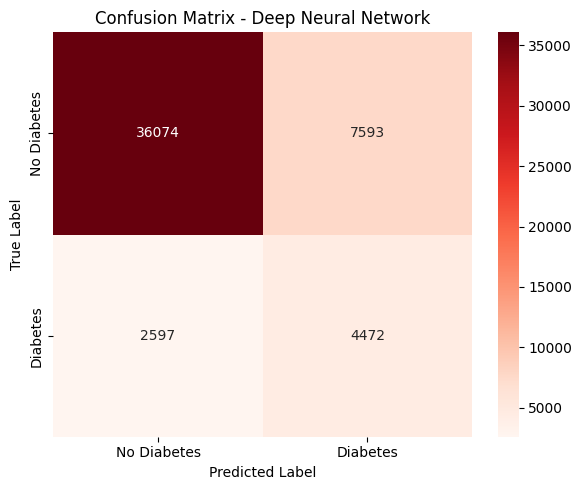

In [10]:
cm = confusion_matrix(y_clf_test, y_pred_deep_nn)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"], ax=ax)
ax.set_title("Confusion Matrix - Deep Neural Network")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [11]:
# Baseline: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_reg_train_s, y_reg_train)
y_pred_linreg = lin_reg.predict(X_reg_test_s)

print("=== Linear Regression ===")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_linreg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_linreg)):.4f}")
print(f"R2:   {r2_score(y_reg_test, y_pred_linreg):.4f}")

=== Linear Regression ===
MAE:  4.3643
RMSE: 6.1749
R2:   0.1230


In [12]:
class SimpleRegressorNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze()


def train_regressor(model, X_train, y_train, epochs=20, lr=0.001):
    dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.FloatTensor(y_train.values),
    )
    loader = DataLoader(dataset, batch_size=512, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    loss_history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {avg_loss:.4f}")

    return model, loss_history


reg_input_dim = X_reg_train_s.shape[1]
simple_reg_nn = SimpleRegressorNN(reg_input_dim)
simple_reg_nn, simple_reg_losses = train_regressor(simple_reg_nn, X_reg_train_s, y_reg_train)

simple_reg_nn.eval()
with torch.no_grad():
    y_pred_simple_reg = simple_reg_nn(torch.FloatTensor(X_reg_test_s)).numpy()

print("\n=== Simple Neural Network - Regression ===")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_simple_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_simple_reg)):.4f}")
print(f"R2:   {r2_score(y_reg_test, y_pred_simple_reg):.4f}")

Epoch 01/20 - Loss: 414.1040
Epoch 02/20 - Loss: 56.0672
Epoch 03/20 - Loss: 44.0687
Epoch 04/20 - Loss: 40.7273
Epoch 05/20 - Loss: 39.2806
Epoch 06/20 - Loss: 38.6019
Epoch 07/20 - Loss: 38.2668
Epoch 08/20 - Loss: 38.0509
Epoch 09/20 - Loss: 37.8577
Epoch 10/20 - Loss: 37.6094
Epoch 11/20 - Loss: 37.3717
Epoch 12/20 - Loss: 37.2364
Epoch 13/20 - Loss: 37.1344
Epoch 14/20 - Loss: 37.0609
Epoch 15/20 - Loss: 37.0131
Epoch 16/20 - Loss: 36.9751
Epoch 17/20 - Loss: 36.9696
Epoch 18/20 - Loss: 36.9650
Epoch 19/20 - Loss: 36.9408
Epoch 20/20 - Loss: 36.8749

=== Simple Neural Network - Regression ===
MAE:  4.2567
RMSE: 6.0733
R2:   0.1516


In [13]:
class DeepRegressorNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze()


deep_reg_nn = DeepRegressorNN(reg_input_dim)
deep_reg_nn, deep_reg_losses = train_regressor(deep_reg_nn, X_reg_train_s, y_reg_train, epochs=30)

deep_reg_nn.eval()
with torch.no_grad():
    y_pred_deep_reg = deep_reg_nn(torch.FloatTensor(X_reg_test_s)).numpy()

print("\n=== Deep Neural Network - Regression ===")
print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_deep_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_deep_reg)):.4f}")
print(f"R2:   {r2_score(y_reg_test, y_pred_deep_reg):.4f}")

Epoch 01/30 - Loss: 221.3232
Epoch 02/30 - Loss: 49.1245
Epoch 03/30 - Loss: 47.6645
Epoch 04/30 - Loss: 47.0638
Epoch 05/30 - Loss: 46.1051
Epoch 06/30 - Loss: 45.6255
Epoch 07/30 - Loss: 44.5589
Epoch 08/30 - Loss: 43.5229
Epoch 09/30 - Loss: 41.9170
Epoch 10/30 - Loss: 40.4771
Epoch 11/30 - Loss: 39.3421
Epoch 12/30 - Loss: 38.6736
Epoch 13/30 - Loss: 38.0198
Epoch 14/30 - Loss: 37.5622
Epoch 15/30 - Loss: 37.3590
Epoch 16/30 - Loss: 37.2320
Epoch 17/30 - Loss: 37.2089
Epoch 18/30 - Loss: 37.2011
Epoch 19/30 - Loss: 37.0489
Epoch 20/30 - Loss: 37.0584
Epoch 21/30 - Loss: 36.9793
Epoch 22/30 - Loss: 36.9112
Epoch 23/30 - Loss: 36.9603
Epoch 24/30 - Loss: 36.9044
Epoch 25/30 - Loss: 36.8625
Epoch 26/30 - Loss: 36.8367
Epoch 27/30 - Loss: 36.8156
Epoch 28/30 - Loss: 36.8020
Epoch 29/30 - Loss: 36.7874
Epoch 30/30 - Loss: 36.7822

=== Deep Neural Network - Regression ===
MAE:  4.1966
RMSE: 6.0301
R2:   0.1637


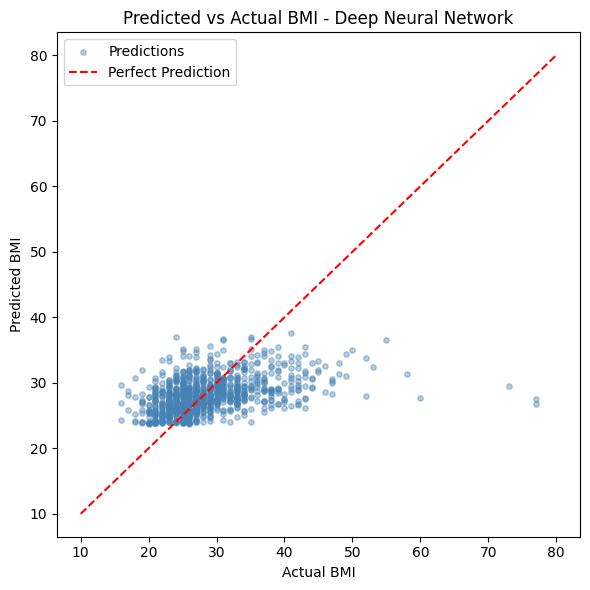

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_reg_test[:1000], y_pred_deep_reg[:1000],
           alpha=0.4, color="steelblue", s=15, label="Predictions")
ax.plot([10, 80], [10, 80], "r--", linewidth=1.5, label="Perfect Prediction")
ax.set_xlabel("Actual BMI")
ax.set_ylabel("Predicted BMI")
ax.set_title("Predicted vs Actual BMI - Deep Neural Network")
ax.legend()

plt.tight_layout()
plt.savefig("bmi_pred_vs_actual.png", dpi=150)
plt.show()

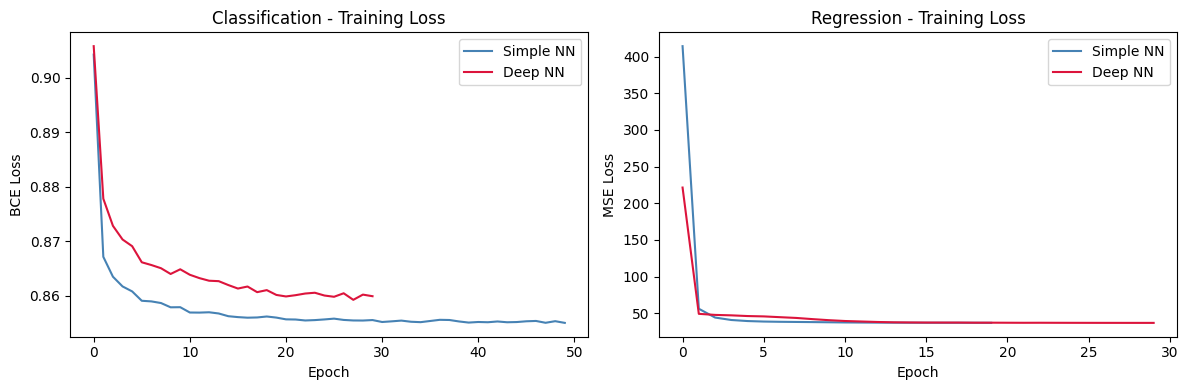

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(simple_clf_losses, label="Simple NN", color="steelblue")
axes[0].plot(deep_clf_losses, label="Deep NN", color="crimson")
axes[0].set_title("Classification - Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()

axes[1].plot(simple_reg_losses, label="Simple NN", color="steelblue")
axes[1].plot(deep_reg_losses, label="Deep NN", color="crimson")
axes[1].set_title("Regression - Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_loss_curves.png", dpi=150)
plt.show()

In [16]:
# Experiment: Log-transform BMI target to reduce skew
y_reg_log = np.log(y_reg)

X_reg_train_log, X_reg_test_log, y_reg_train_log, y_reg_test_log = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=42
)

scaler_log = StandardScaler()
X_reg_train_log_s = scaler_log.fit_transform(X_reg_train_log)
X_reg_test_log_s = scaler_log.transform(X_reg_test_log)

deep_reg_log = DeepRegressorNN(X_reg_train_log_s.shape[1])
deep_reg_log, _ = train_regressor(deep_reg_log, X_reg_train_log_s, y_reg_train_log, epochs=50)

deep_reg_log.eval()
with torch.no_grad():
    y_pred_log = deep_reg_log(torch.FloatTensor(X_reg_test_log_s)).numpy()

# Inverse transform to get original BMI scale
y_pred_exp = np.exp(y_pred_log)
y_test_exp = np.exp(y_reg_test_log)

print("=== Deep NN Regression - Log Transform ===")
print(f"MAE:  {mean_absolute_error(y_test_exp, y_pred_exp):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_exp, y_pred_exp)):.4f}")
print(f"R2:   {r2_score(y_test_exp, y_pred_exp):.4f}")

Epoch 01/50 - Loss: 0.7220
Epoch 02/50 - Loss: 0.1663
Epoch 03/50 - Loss: 0.0880
Epoch 04/50 - Loss: 0.0458
Epoch 05/50 - Loss: 0.0397
Epoch 06/50 - Loss: 0.0388
Epoch 07/50 - Loss: 0.0385
Epoch 08/50 - Loss: 0.0382
Epoch 09/50 - Loss: 0.0380
Epoch 10/50 - Loss: 0.0378
Epoch 11/50 - Loss: 0.0377
Epoch 12/50 - Loss: 0.0376
Epoch 13/50 - Loss: 0.0375
Epoch 14/50 - Loss: 0.0374
Epoch 15/50 - Loss: 0.0374
Epoch 16/50 - Loss: 0.0373
Epoch 17/50 - Loss: 0.0373
Epoch 18/50 - Loss: 0.0371
Epoch 19/50 - Loss: 0.0371
Epoch 20/50 - Loss: 0.0370
Epoch 21/50 - Loss: 0.0370
Epoch 22/50 - Loss: 0.0370
Epoch 23/50 - Loss: 0.0368
Epoch 24/50 - Loss: 0.0367
Epoch 25/50 - Loss: 0.0368
Epoch 26/50 - Loss: 0.0365
Epoch 27/50 - Loss: 0.0365
Epoch 28/50 - Loss: 0.0365
Epoch 29/50 - Loss: 0.0365
Epoch 30/50 - Loss: 0.0364
Epoch 31/50 - Loss: 0.0364
Epoch 32/50 - Loss: 0.0364
Epoch 33/50 - Loss: 0.0363
Epoch 34/50 - Loss: 0.0364
Epoch 35/50 - Loss: 0.0363
Epoch 36/50 - Loss: 0.0363
Epoch 37/50 - Loss: 0.0363
E